In [2]:
from google.colab import drive
drive.mount('/content/drive')
#/content/drive/MyDrive/Thesis/figures/
# /content/drive/MyDrive/Thesis/datasets/
# /content/drive/MyDrive/Thesis/pickles/

Mounted at /content/drive


In [3]:
from scipy.spatial.distance import jensenshannon
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Thesis/datasets/german_credit_train.csv')

# COLUMN CLASSIFICATION
categorical_cols = [
    'checking_account_status', 'credit_history', 'purpose', 'savings_account',
    'employment_duration', 'sex', 'other_debtors', 'property',
    'other_installment_plans', 'housing', 'job', 'telephone',
    'foreign_worker', 'target', 'relationship_status'
]

discrete_cols = [
    'installment_rate', 'residence_duration',
    'existing_credits', 'num_dependents'
]

continuous_cols = ['duration_months', 'credit_amount', 'age']

# SYNTHETIC DATASETS
synthetic_datasets = {
    'config default': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_default.csv'),
    'config 1': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#1.csv'),
    'config 2': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#2.csv'),
    'config 3': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#3.csv'),
    'config 4': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#4.csv'),
    'config 5': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#5.csv'),
    'config 6': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#6.csv'),
    'config 7': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#7.csv'),
    'config 8': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#8.csv'),
    'config 9': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#9.csv'),
    # 'config 10': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#10.csv'),
    # 'config 11': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#11.csv'),
    'config 12': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#12.csv'),
    'config 13': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#13.csv'),
    'config 14': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#14.csv'),
    'config 15': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#15.csv'),
    'config 16': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#16.csv'),
    'config 17': pd.read_csv('/content/drive/MyDrive/Thesis/Datasets/synthetic_data_config#17.csv'),

}


fidelity_results = []

for config_name, syn_df in synthetic_datasets.items():
    row = {'configuration': config_name}

    # 1. JSD for Categorical & Discrete Columns
    for col in categorical_cols + discrete_cols:
        real_probs = df[col].value_counts(normalize=True)
        syn_probs  = syn_df[col].value_counts(normalize=True)

        # Align indices (in case a rare category is missing in the synthetic data)
        all_cats   = real_probs.index.union(syn_probs.index)
        real_probs = real_probs.reindex(all_cats, fill_value=0)
        syn_probs  = syn_probs.reindex(all_cats, fill_value=0)

        # Calculate JSD
        row[f'jsd_{col}'] = round(jensenshannon(real_probs, syn_probs), 4)

    # 2. JSD for Continuous Columns
    for col in continuous_cols:
        combined  = pd.concat([df[col], syn_df[col]])
        bin_edges = np.linspace(combined.min(), combined.max(), 51)
        real_hist, _ = np.histogram(df[col],     bins=bin_edges, density=True)
        syn_hist,  _ = np.histogram(syn_df[col], bins=bin_edges, density=True)

        # Prevent division by zero errors in the JSD calculation
        real_hist += 1e-10
        syn_hist  += 1e-10
        row[f'jsd_{col}'] = round(jensenshannon(real_hist, syn_hist), 4)

    fidelity_results.append(row)

fidelity_df = pd.DataFrame(fidelity_results)

# 3. Create the Summary
jsd_cols = [col for col in fidelity_df.columns if col.startswith('jsd_')]

summary_df = pd.DataFrame({
    'configuration': fidelity_df['configuration'],
    'avg_jsd': fidelity_df[jsd_cols].mean(axis=1)
})

print("\n── Final Summary (Sorted by Best Global Fidelity) ──")
print(summary_df.sort_values(by='avg_jsd').to_string())


── Final Summary (Sorted by Best Global Fidelity) ──
     configuration   avg_jsd
15       config 17  0.066923
8         config 8  0.075014
14       config 16  0.076232
13       config 15  0.087918
12       config 14  0.091000
11       config 13  0.099650
1         config 1  0.102023
0   config default  0.102068
10       config 12  0.102418
5         config 5  0.120964
2         config 2  0.127541
3         config 3  0.127677
7         config 7  0.141973
4         config 4  0.147577
6         config 6  0.224691
9         config 9  0.249382


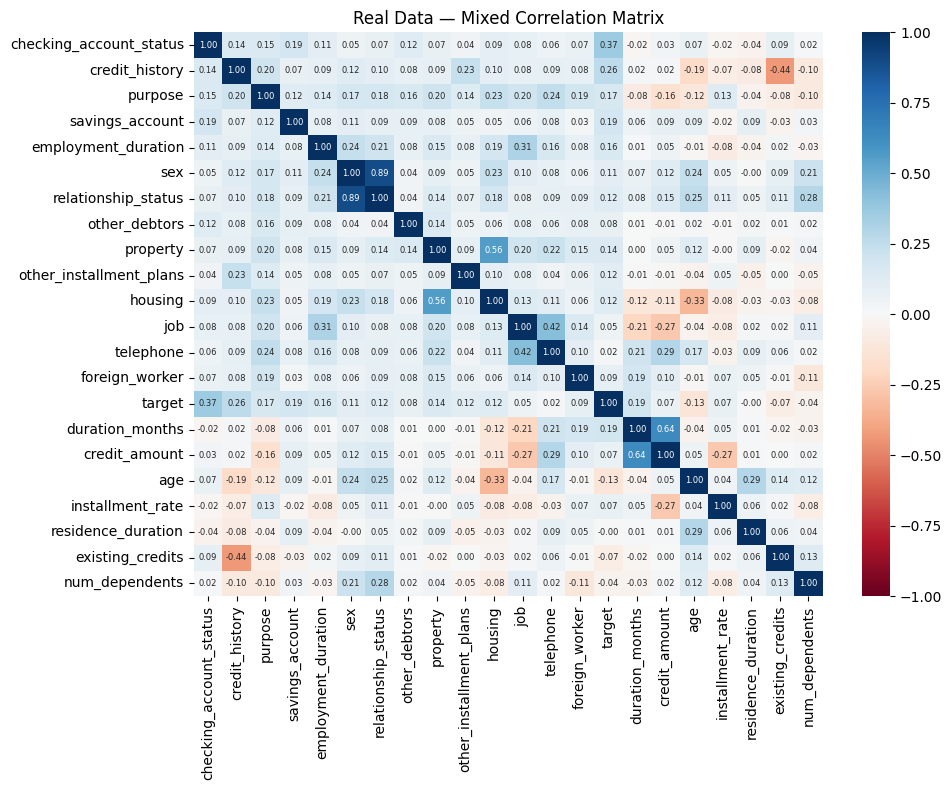

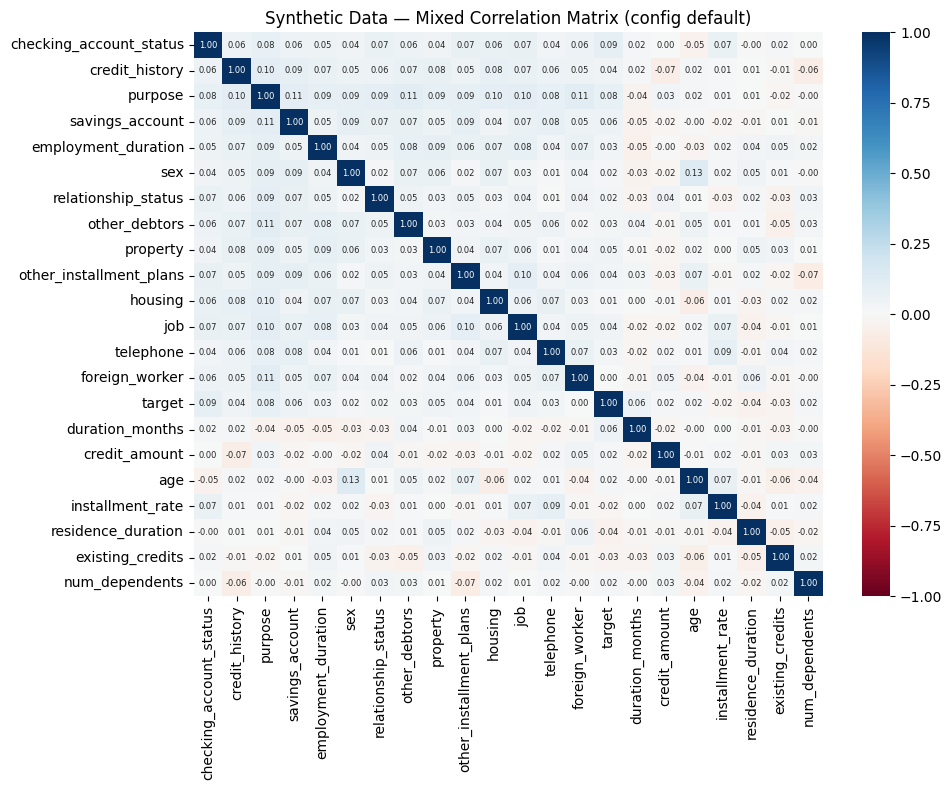

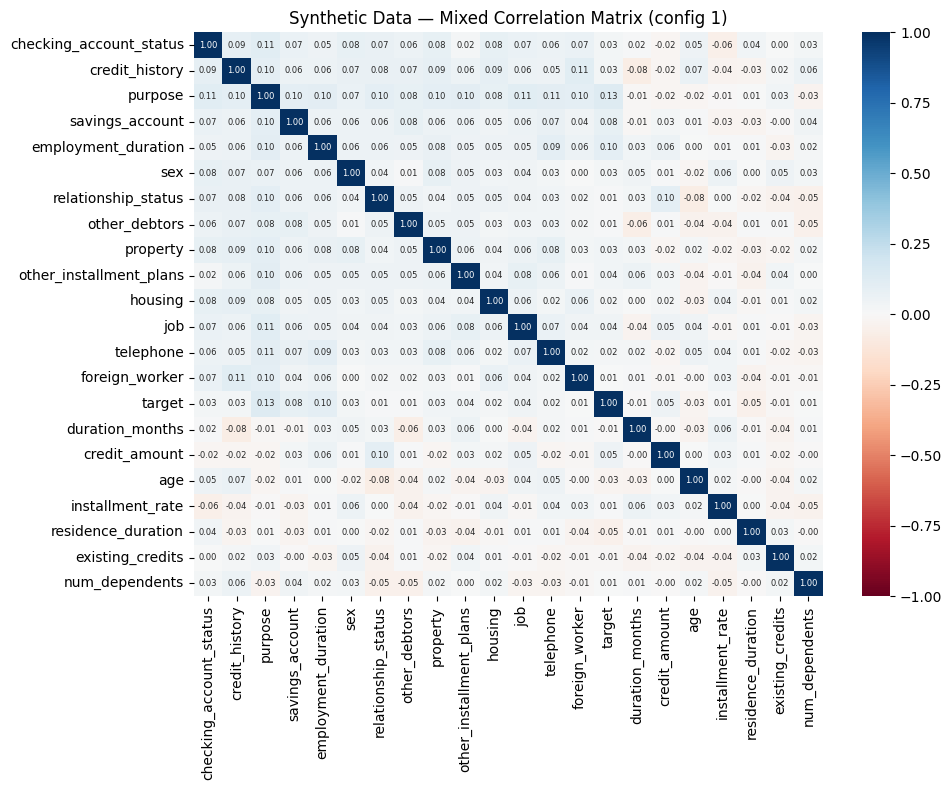

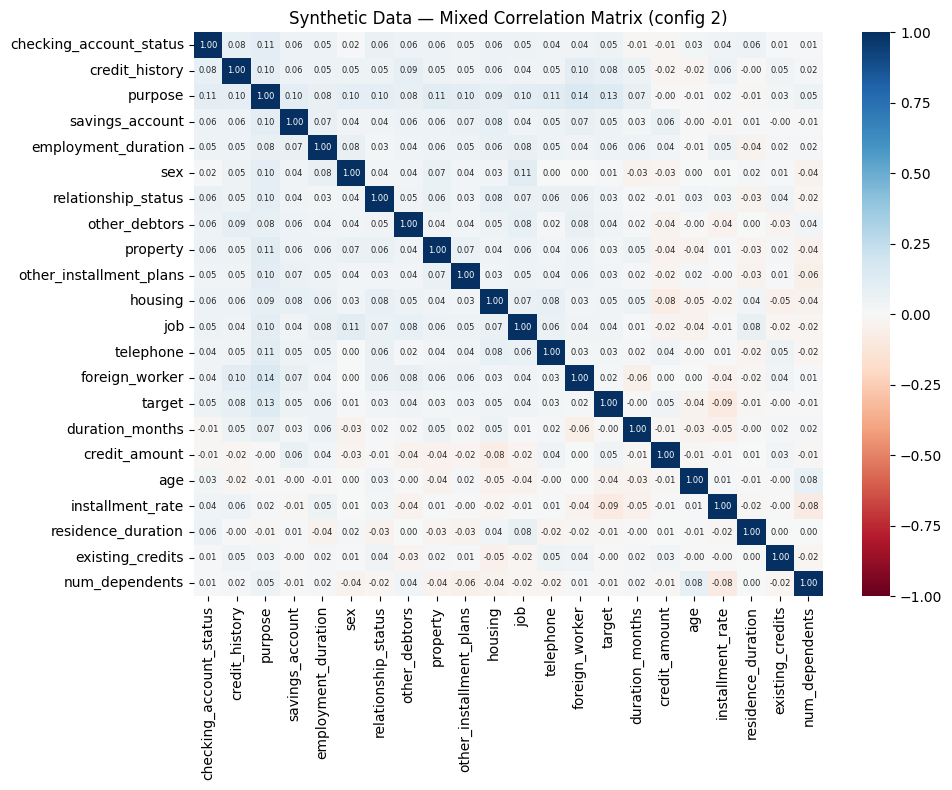

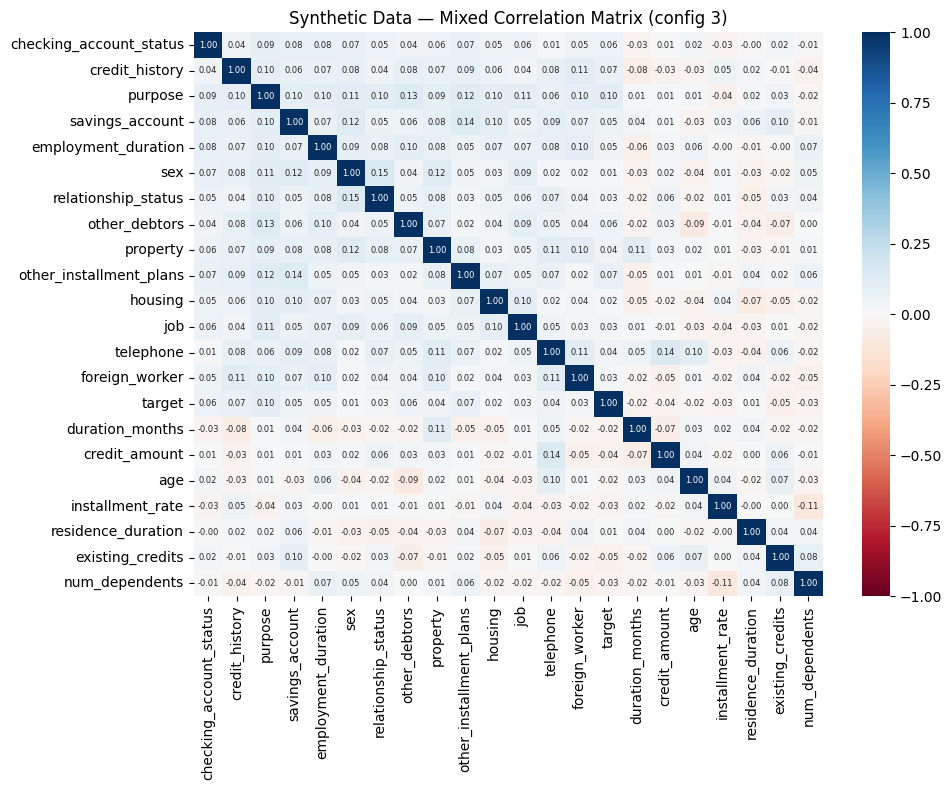

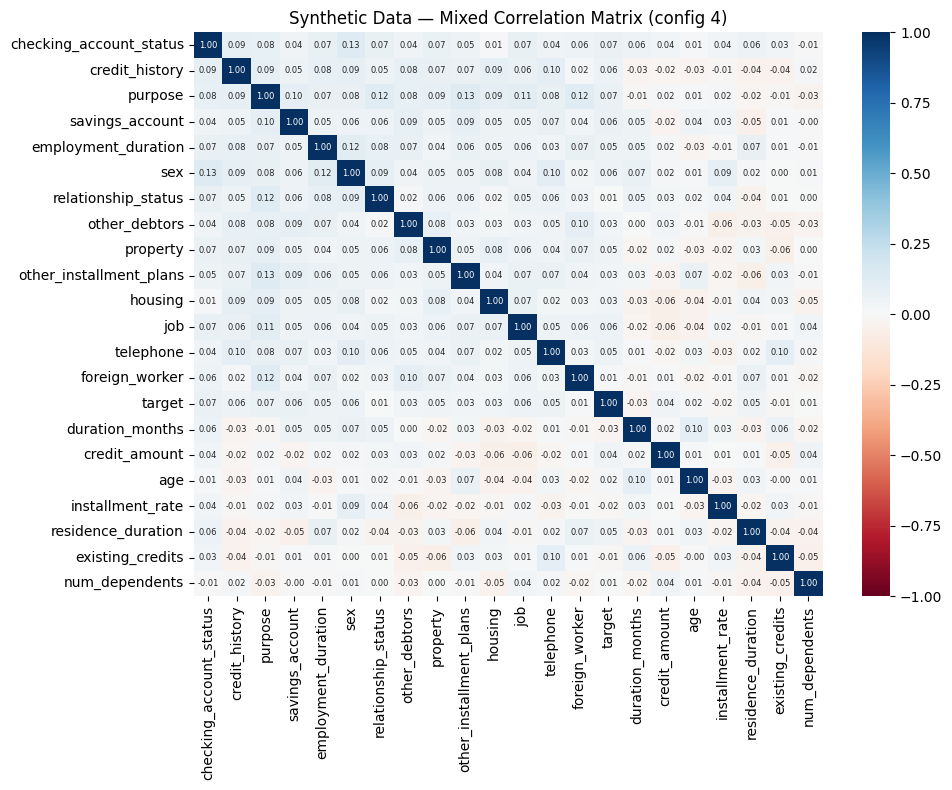

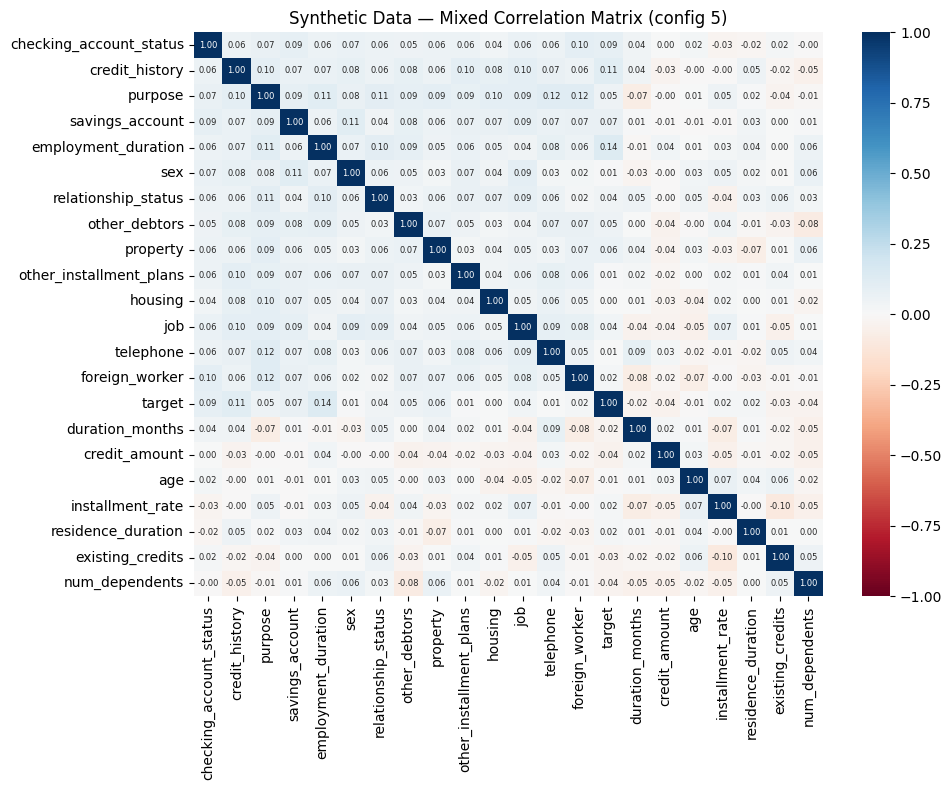

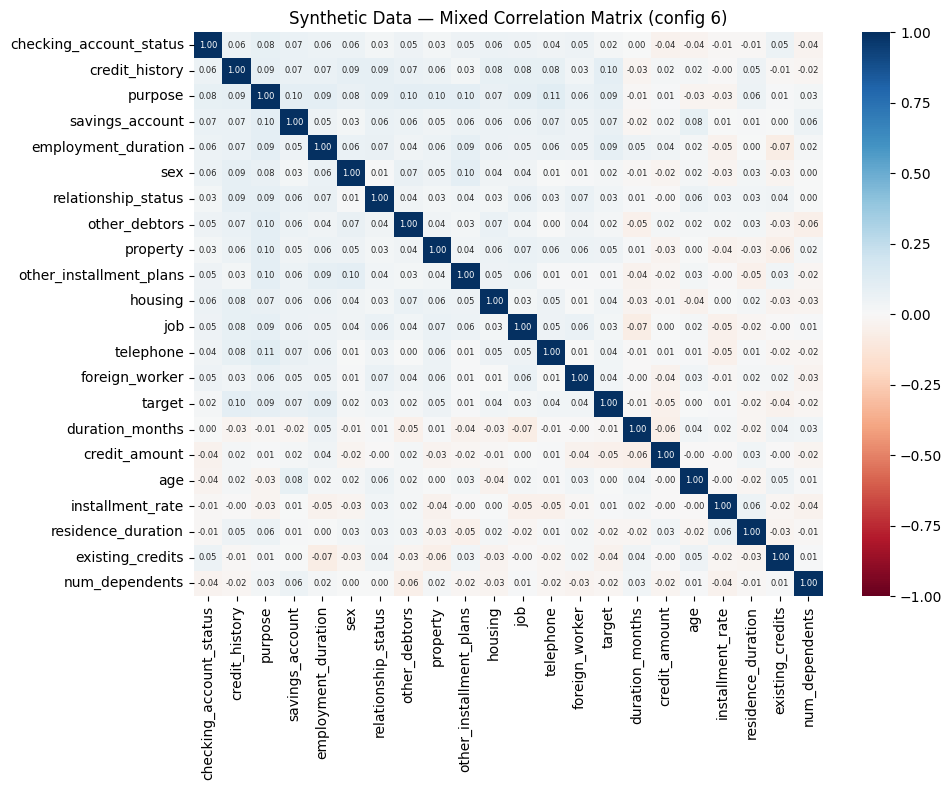

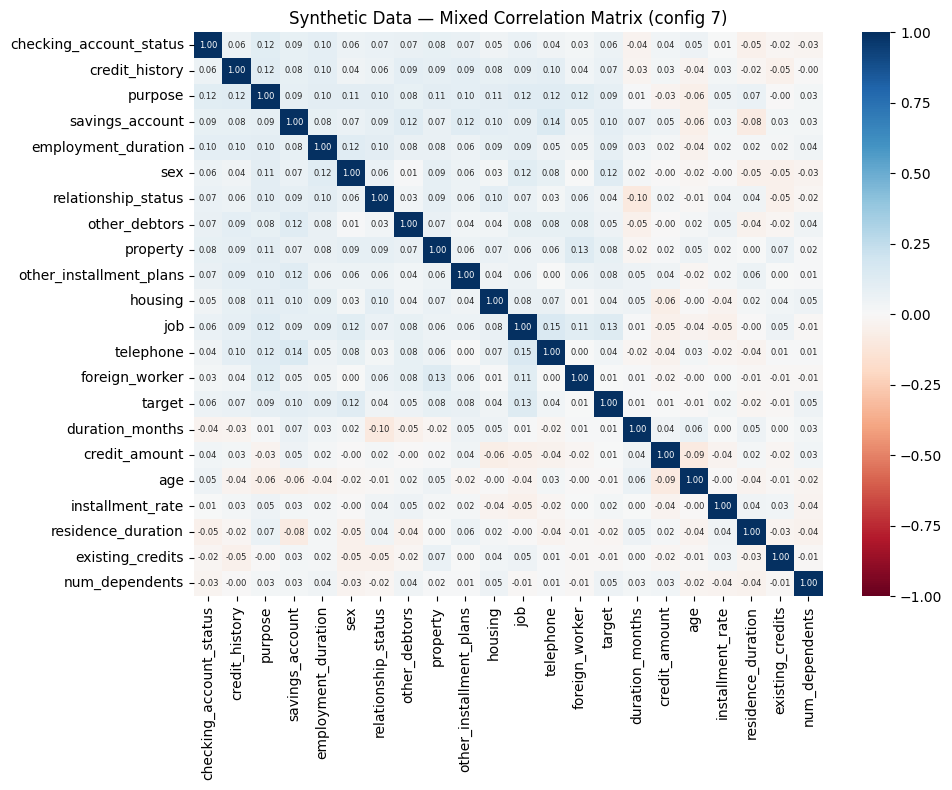

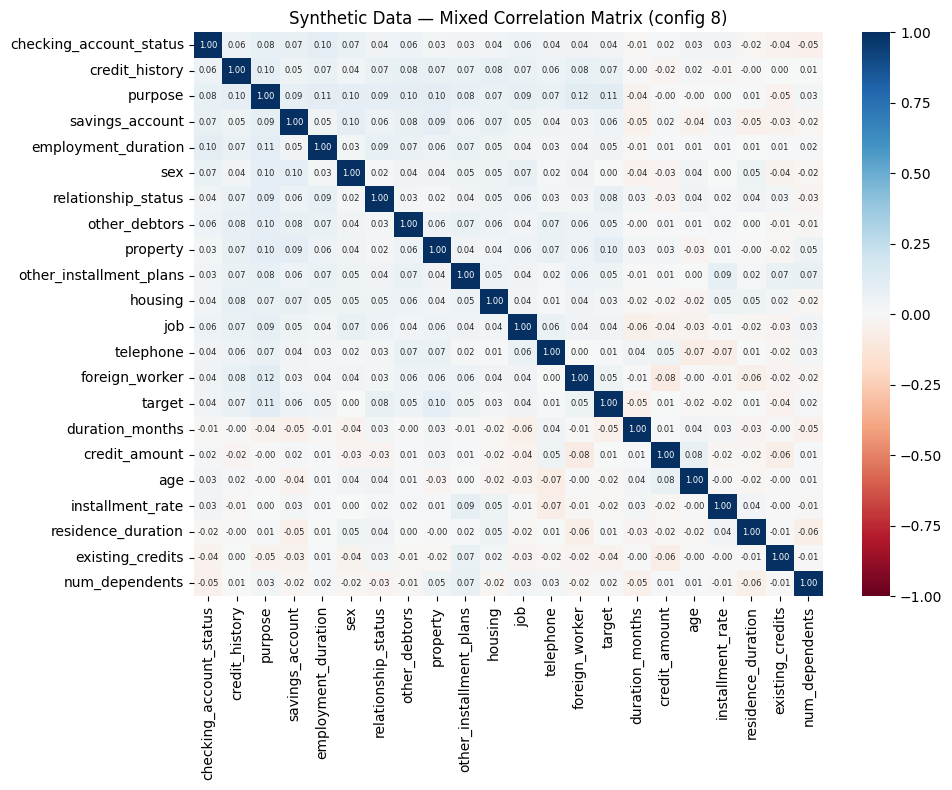

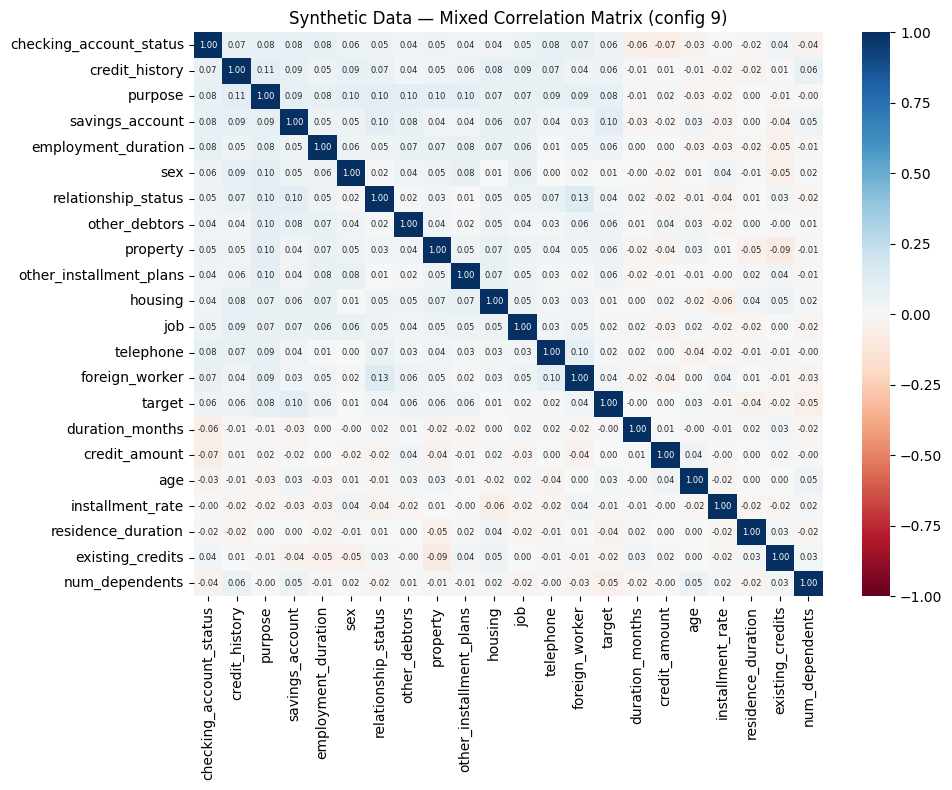

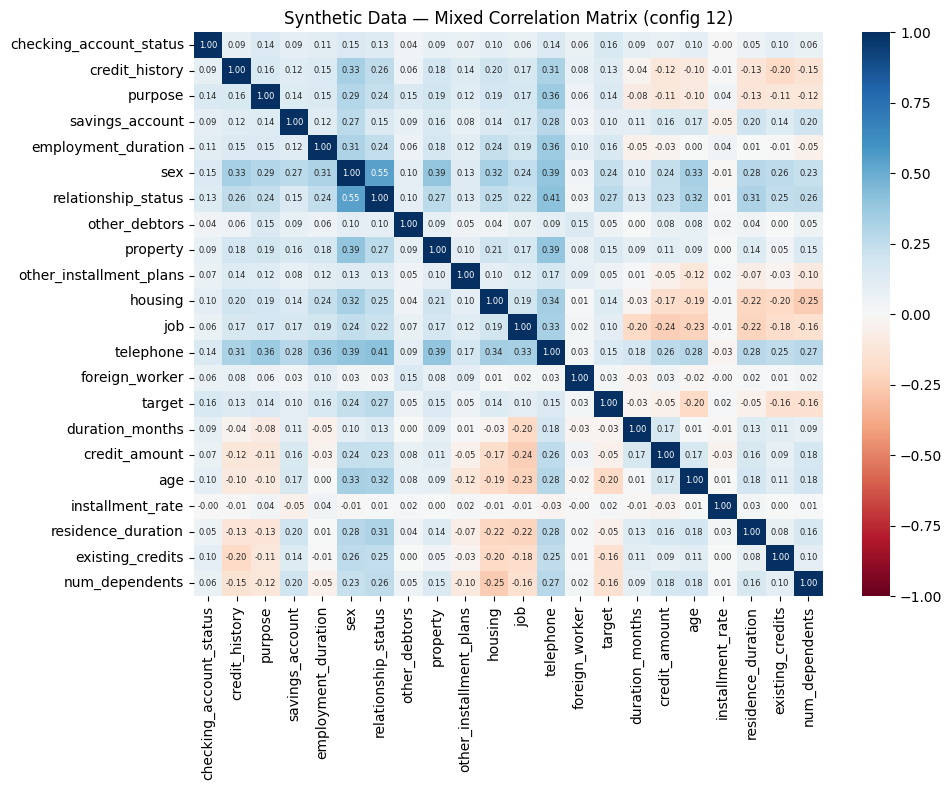

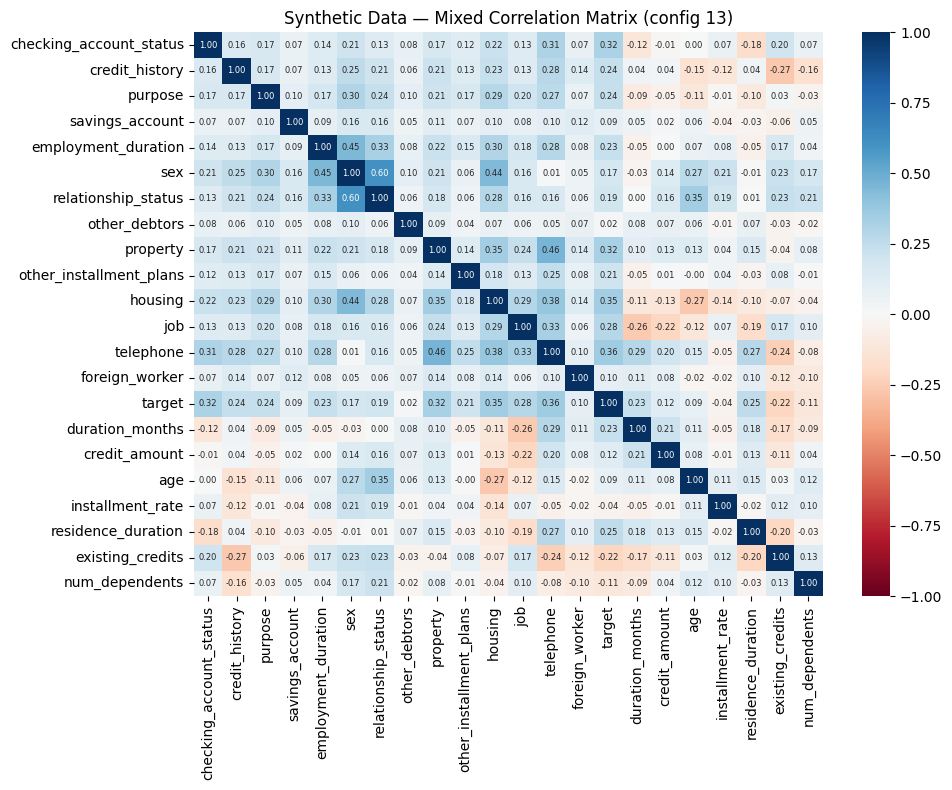

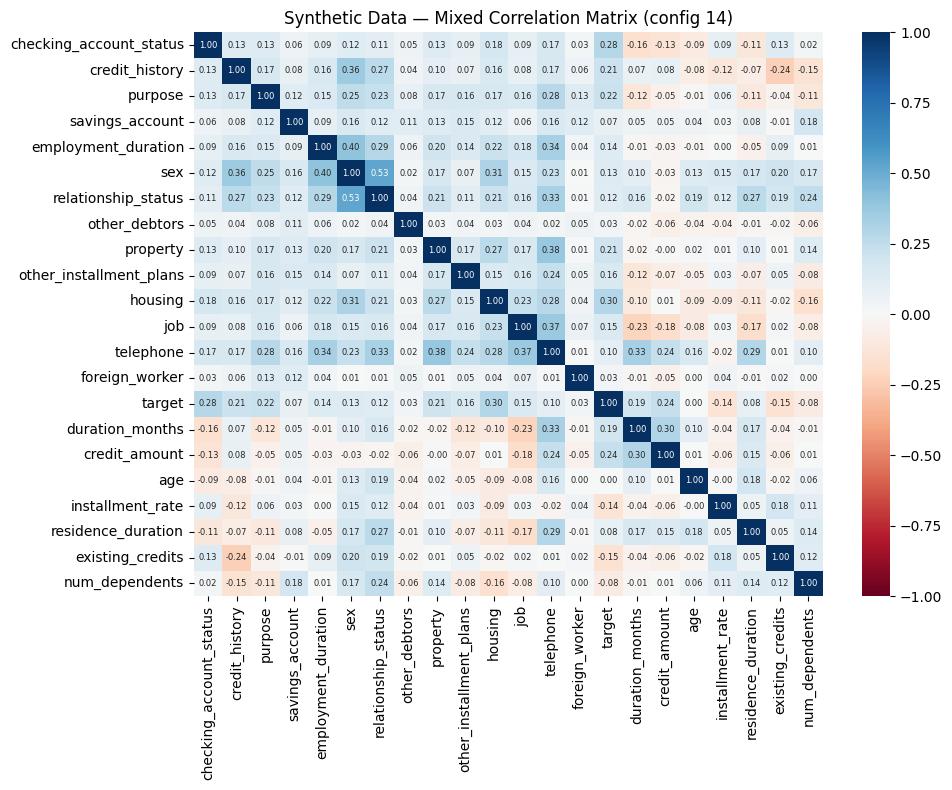

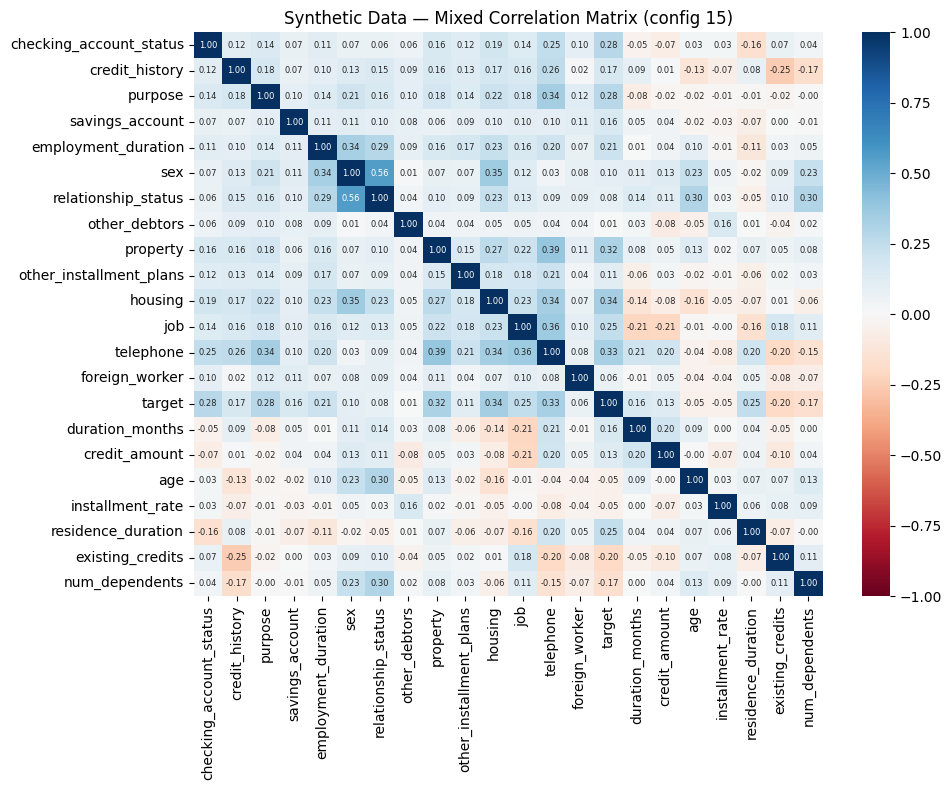

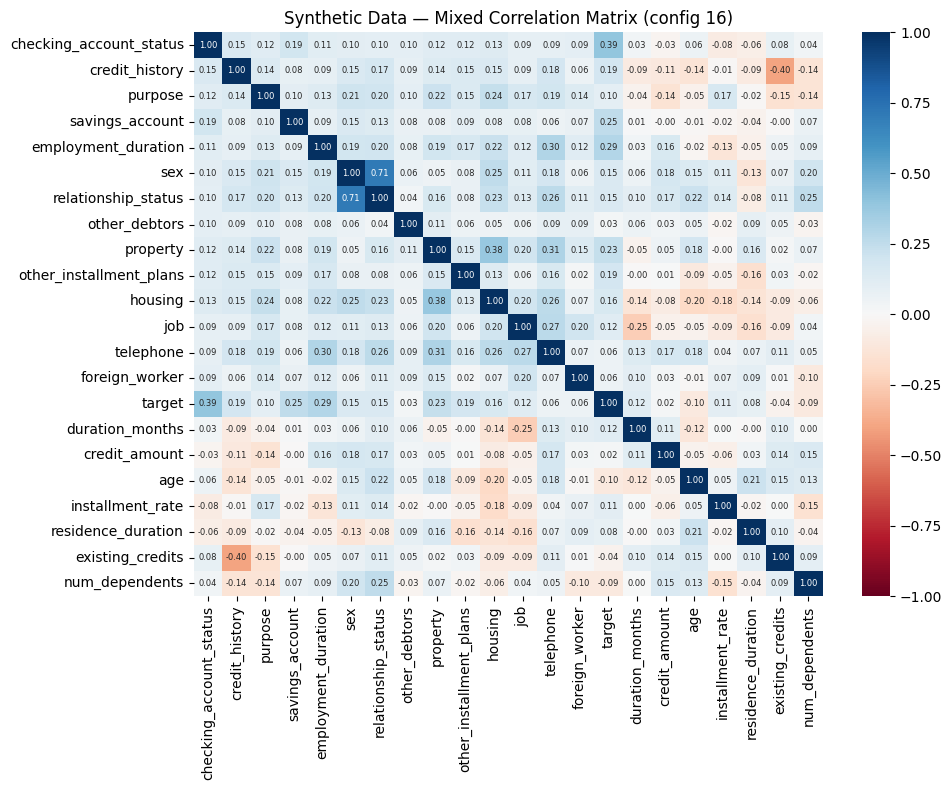

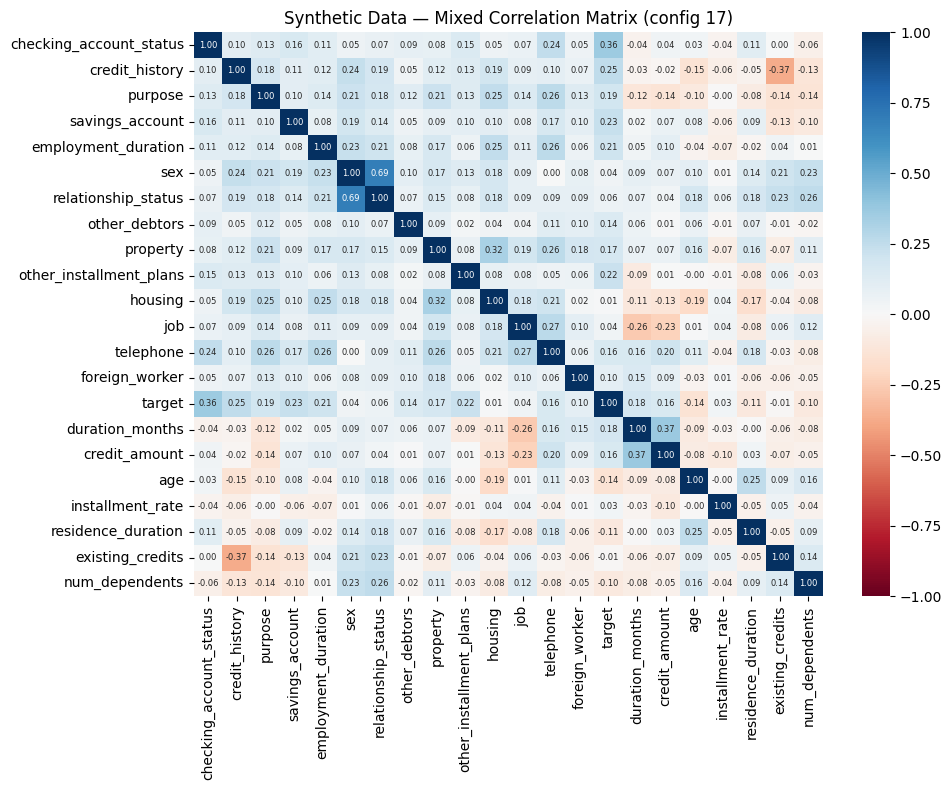

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    if min(r, k) - 1 == 0:
        return 0.0
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def compute_mixed_correlation(df, categorical_cols, numerical_cols):
    all_cols = categorical_cols + numerical_cols
    corr_matrix = pd.DataFrame(
        np.zeros((len(all_cols), len(all_cols))),
        index=all_cols, columns=all_cols
    )

    for col in all_cols:
        corr_matrix.loc[col, col] = 1.0

    # Cramér's V for categorical-categorical pairs
    for i, col1 in enumerate(categorical_cols):
        for col2 in categorical_cols[i+1:]:
            v = cramers_v(df[col1].astype(str), df[col2].astype(str))
            corr_matrix.loc[col1, col2] = v
            corr_matrix.loc[col2, col1] = v

    # Pearson for numerical-numerical pairs
    for i, col1 in enumerate(numerical_cols):
        for col2 in numerical_cols[i+1:]:
            r = df[col1].corr(df[col2])
            corr_matrix.loc[col1, col2] = r
            corr_matrix.loc[col2, col1] = r

    # Spearman for categorical-numerical pairs
    for cat_col in categorical_cols:
        for num_col in numerical_cols:
            encoded = df[cat_col].astype('category').cat.codes
            r = encoded.corr(df[num_col], method='spearman')
            corr_matrix.loc[cat_col, num_col] = r
            corr_matrix.loc[num_col, cat_col] = r

    return corr_matrix.astype(float)

categorical_cols = [
    'checking_account_status', 'credit_history', 'purpose',
    'savings_account', 'employment_duration', 'sex',
    'relationship_status', 'other_debtors', 'property',
    'other_installment_plans', 'housing', 'job',
    'telephone', 'foreign_worker', 'target'
]

numerical_cols = [
    'duration_months', 'credit_amount', 'age',
    'installment_rate', 'residence_duration',
    'existing_credits', 'num_dependents'
]



# Compute real data correlation once
real_corr = compute_mixed_correlation(df, categorical_cols, numerical_cols)
# --- Real data heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(real_corr, annot=True, fmt='.2f', cmap='RdBu',
              vmin=-1, vmax=1, annot_kws={'size': 6})
plt.title('Real Data — Mixed Correlation Matrix')
plt.tight_layout()
plt.savefig(
    f"/content/drive/MyDrive/Thesis/figures/correlation_heatmap_real.pdf",
    bbox_inches='tight', dpi=300
)
plt.show()
plt.close()
# Loop over all configs
cramer_results = []
for config_name, syn_df in synthetic_datasets.items():
    syn_corr = compute_mixed_correlation(syn_df, categorical_cols, numerical_cols)
    # safe_name = config_name.replace(' ', '_').replace('#', '')

    # --- Synthetic data heatmap ---
    plt.figure(figsize=(10, 8))
    sns.heatmap(syn_corr, annot=True, fmt='.2f', cmap='RdBu',
                vmin=-1, vmax=1, annot_kws={'size': 6})
    plt.title(f'Synthetic Data — Mixed Correlation Matrix ({config_name})')
    plt.tight_layout()

    # fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # sns.heatmap(real_corr, annot=True, fmt='.2f', cmap='RdBu',
    #             vmin=-1, vmax=1, ax=axes[0], annot_kws={'size': 6})
    # axes[0].set_title('Real Data — Mixed Correlation Matrix')

    # sns.heatmap(syn_corr, annot=True, fmt='.2f', cmap='RdBu',
    #             vmin=-1, vmax=1, ax=axes[1], annot_kws={'size': 6})
    # axes[1].set_title(f'Synthetic Data — Mixed Correlation Matrix ({config_name})')

    # plt.suptitle(f'Correlation Heatmap Comparison — {config_name}', y=1.02)
    # plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/Thesis/figures/correlation_heatmap_{config_name}.pdf",
        bbox_inches='tight', dpi=300
    )
    plt.show()
    plt.close()

    # cramer values
    real_cramer_block = real_corr.loc[categorical_cols, categorical_cols]
    syn_cramer_block  = syn_corr.loc[categorical_cols, categorical_cols]
    mask = ~np.eye(len(categorical_cols), dtype=bool)
    mad_cramer = (real_cramer_block - syn_cramer_block).abs().values[mask].mean()
    cramer_results.append({
    'configuration': config_name,
    'mean_abs_diff_cramerV': round(mad_cramer, 4)
    })